In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning (optional forecasting)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [ ]:
import os

# Create main project folder
if not os.path.exists('Uber_Ride_Analysis'):
    os.makedirs('Uber_Ride_Analysis')

# Subfolders
os.makedirs('Uber_Ride_Analysis/data', exist_ok=True)
os.makedirs('Uber_Ride_Analysis/figures', exist_ok=True)
os.makedirs('Uber_Ride_Analysis/notebooks', exist_ok=True)

In [ ]:
import os

# Create figures folder in Colab
if not os.path.exists('figures'):
    os.makedirs('figures')

In [ ]:
df = pd.read_csv("uberdrive.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [ ]:
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [ ]:
df.describe()

,MILES*
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [ ]:
df.shape

(1156, 7)

In [ ]:
# Show all columns exactly as they are
print(df.columns.tolist())

['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*', 'PURPOSE*']


In [ ]:
# See how the dates look
print(df['START_DATE*'].head(10))

0    01-01-2016 21:11
1    01-02-2016 01:25
2    01-02-2016 20:25
3    01-05-2016 17:31
4    01-06-2016 14:42
5    01-06-2016 17:15
6    01-06-2016 17:30
7    01-07-2016 13:27
8    01-10-2016 08:05
9    01-10-2016 12:17
Name: START_DATE*, dtype: object


In [ ]:
df['start_time'] = pd.to_datetime(df['START_DATE*'], errors='coerce')
df['end_time'] = pd.to_datetime(df['END_DATE*'], errors='coerce')

# Check how many failed to convert
print(df['start_time'].isna().sum(), "rows failed to convert")

735 rows failed to convert


In [ ]:
df = df.dropna(subset=['start_time', 'end_time'])

In [ ]:
df.loc[:, 'hour'] = df['start_time'].dt.hour
df.loc[:, 'day_of_week'] = df['start_time'].dt.day_name()
df.loc[:, 'month'] = df['start_time'].dt.month

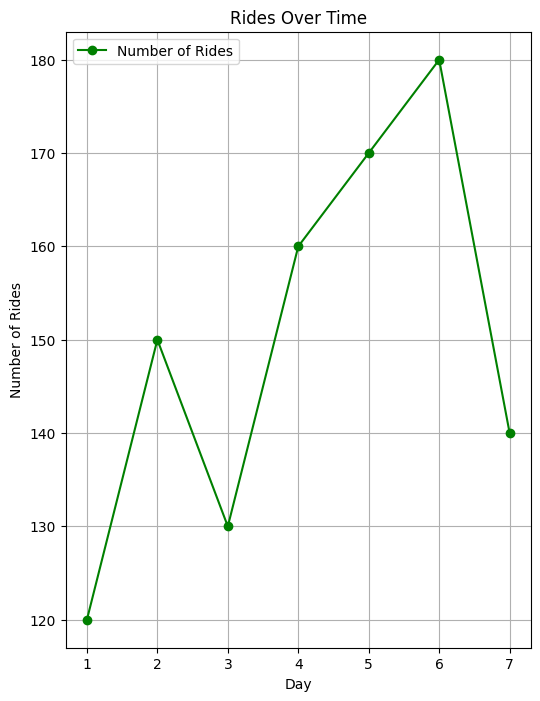

In [ ]:


import matplotlib.pyplot as plt

# Example data
days = [1, 2, 3, 4, 5, 6, 7]            # X-axis
rides_per_day = [120, 150, 130, 160, 170, 180, 140]  # Y-axis

# Create figure with proper size
plt.figure(figsize=(6,8))

# Plot data
plt.plot(days, rides_per_day, marker='o', color='green', label="Number of Rides")

# Add title and labels
plt.title("Rides Over Time")
plt.xlabel("Day")
plt.ylabel("Number of Rides")
plt.grid(True)
plt.legend()

# **Save AFTER plotting** (this is important!)
plt.savefig("/content/rides_over_time.png", dpi=150, bbox_inches='tight')

# Display in notebook
plt.show()

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
plt.savefig("rides_over_time.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

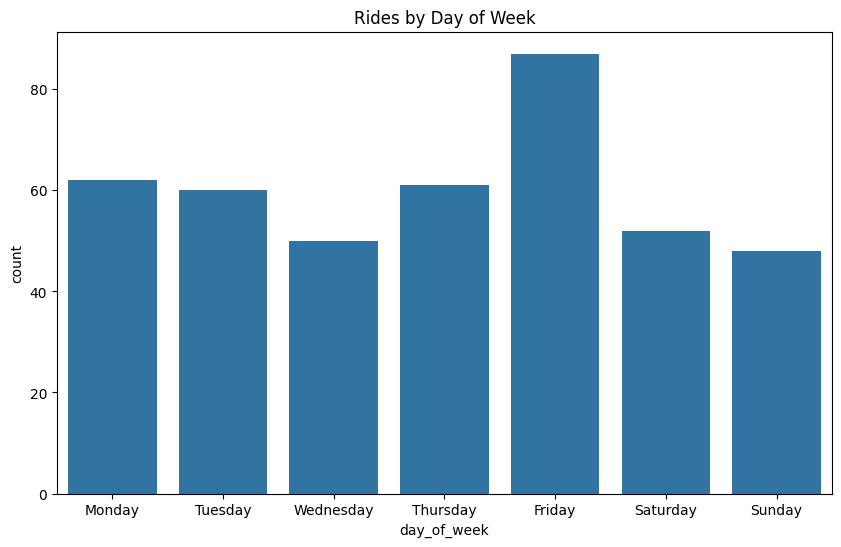

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='day_of_week', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Rides by Day of Week')
plt.show()

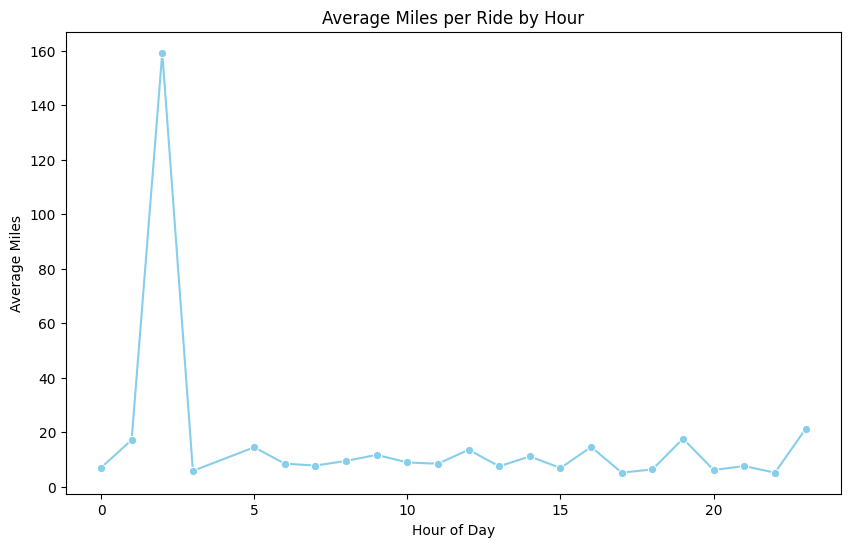

In [ ]:
# Example: average miles per hour
avg_miles_per_hour = df.groupby('hour')['MILES*'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(x='hour', y='MILES*', data=avg_miles_per_hour, marker='o', color='skyblue')
plt.title('Average Miles per Ride by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Miles')
plt.show()

In [ ]:
pivot = df.pivot_table(
    index='day_of_week',
    columns='hour',
    values='START_DATE*',  # Use any column that exists
    aggfunc='count'
).fillna(0)

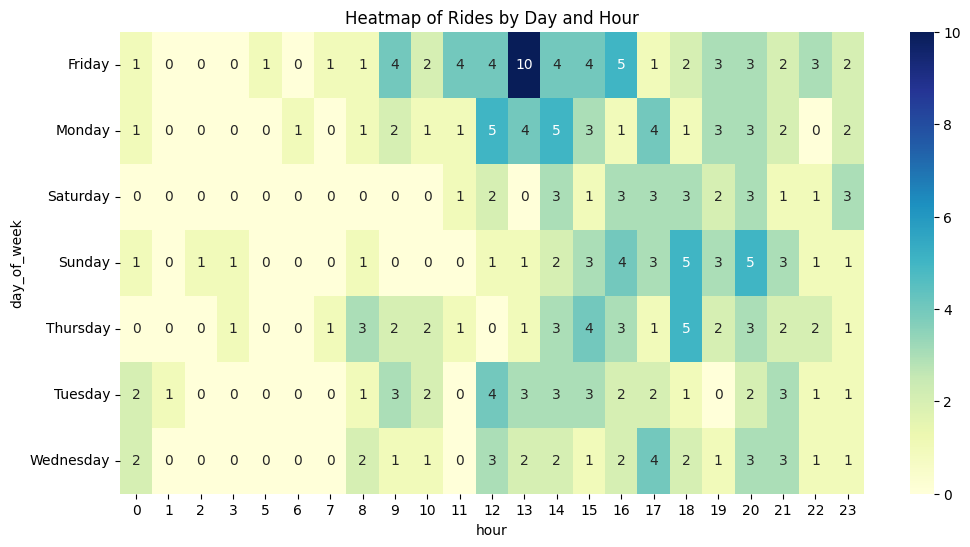

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Heatmap of Rides by Day and Hour')
plt.show()

In [ ]:
import os
os.makedirs('Uber_Ride_Analysis/figures', exist_ok=True)

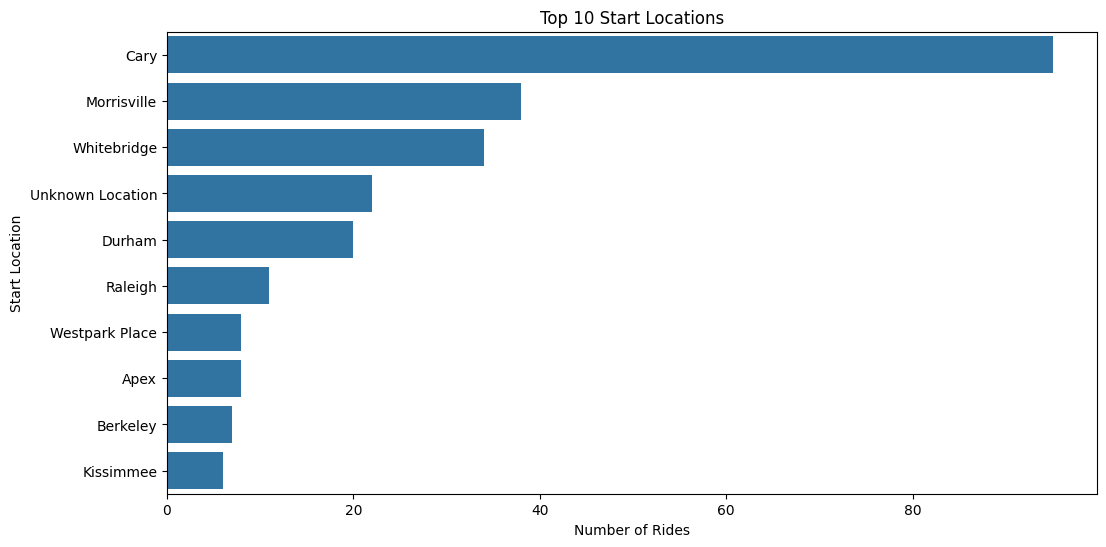

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# create folder
os.makedirs('Uber_Ride_Analysis/figures', exist_ok=True)

# Top 10 start locations
top_start = df['START*'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_start.values, y=top_start.index)

plt.title('Top 10 Start Locations')
plt.xlabel('Number of Rides')
plt.ylabel('Start Location')

plt.savefig('Uber_Ride_Analysis/figures/top_start_locations.png', dpi=300, bbox_inches='tight')
plt.show()

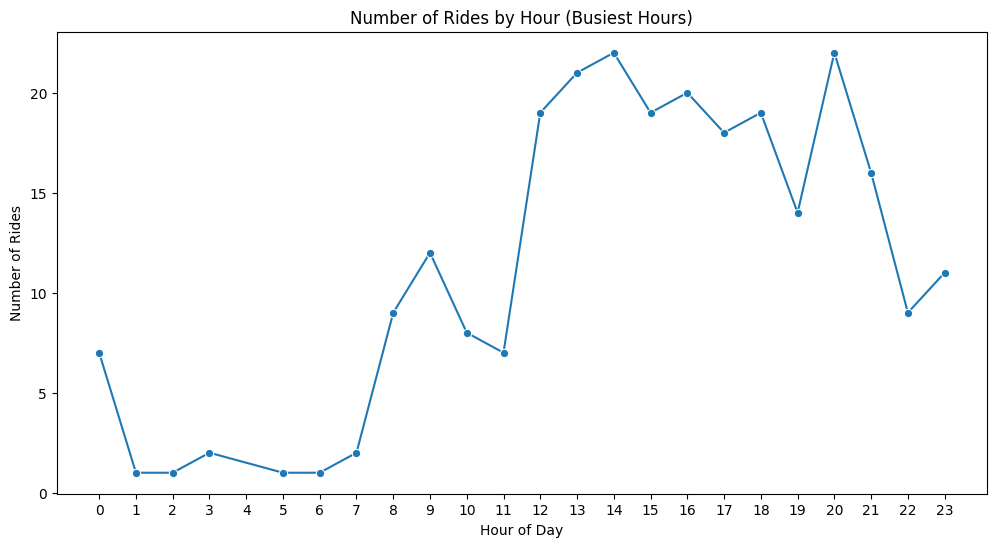

In [ ]:
hour_counts = df['hour'].value_counts().sort_index()  # 0-23 hours

plt.figure(figsize=(12,6))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o')
plt.title('Number of Rides by Hour (Busiest Hours)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0,24))
plt.savefig('Uber_Ride_Analysis/figures/busiest_hours.png', dpi=300, bbox_inches='tight')
plt.show()

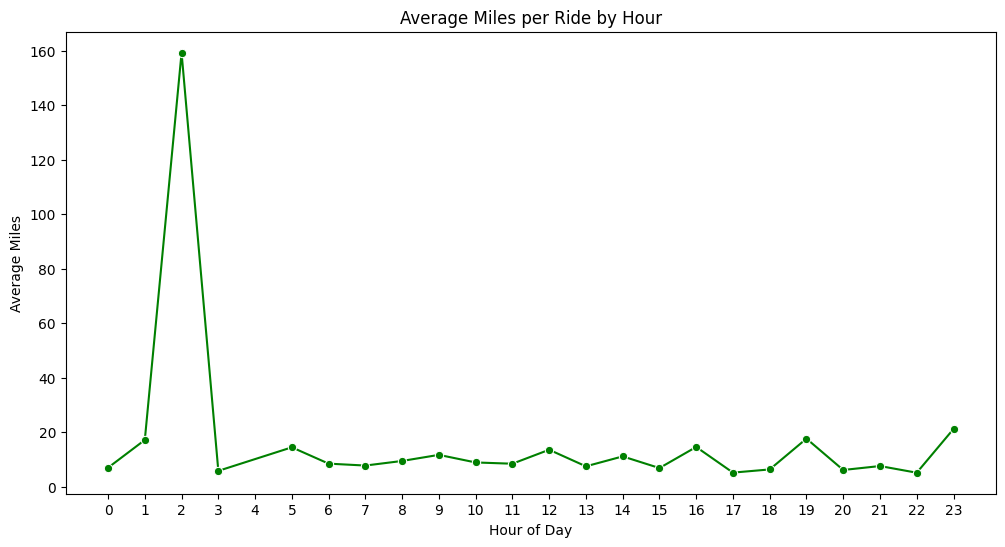

In [ ]:
avg_miles = df.groupby('hour')['MILES*'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='hour', y='MILES*', data=avg_miles, marker='o', color='green')
plt.title('Average Miles per Ride by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Miles')
plt.xticks(range(0,24))
plt.savefig('Uber_Ride_Analysis/figures/avg_miles_hour.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Prepare data
df_hourly = df.groupby(['hour', 'day_of_week']).size().reset_index(name='ride_count')
X = pd.get_dummies(df_hourly[['hour','day_of_week']], drop_first=True)
y = df_hourly['ride_count']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse}')

RMSE: 1.2833493370384212
